In [ ]:
# Slide 5
# Image Data
# https://www.imageprocessingplace.com/DIP-3E/dip3e_book_images_downloads.htm

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Suppress OpenCV Warnings
os.environ["OPENCV_LOG_LEVEL"] = "ERROR"

def show_3_in_1(original, img1, img2, title1, title2):
    plt.figure(figsize=(15, 5))

    # Original
    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray', vmin=0, vmax=255)
    plt.title("Original")
    plt.axis('off')

    # Transformation 1
    plt.subplot(1, 3, 2)
    plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
    plt.title(title1)
    plt.axis('off')

    # Transformation 2
    plt.subplot(1, 3, 3)
    plt.imshow(img2, cmap='gray', vmin=0, vmax=255)
    plt.title(title2)
    plt.axis('off')

    plt.show()

def normalize(img):
    # Normalize derivative values to 0-255 for visualization
    return cv2.normalize(np.abs(img), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

5.1 1st Derivative Filter

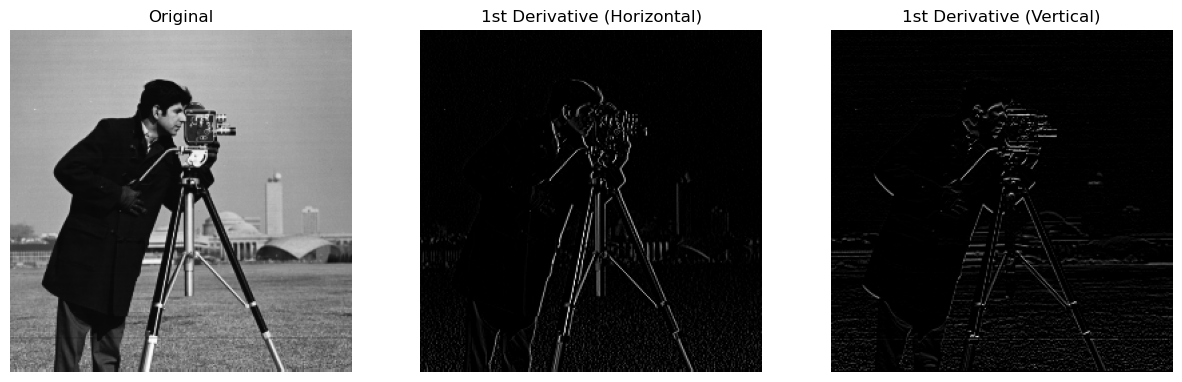

In [ ]:
# 5.1 – First derivative using simple difference (Horizontal vs Vertical)

# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Manual Kernels
# Horizontal: [-1, 1]
k_hor = np.array([[-1, 1]], dtype=np.float32)
# Vertical: [-1, 1] Transposed
k_ver = np.array([[-1], [1]], dtype=np.float32)

deriv_h = cv2.filter2D(img, -1, k_hor)
deriv_v = cv2.filter2D(img, -1, k_ver)

show_3_in_1(img, normalize(deriv_h), normalize(deriv_v), "1st Derivative (Horizontal)", "1st Derivative (Vertical)")

5.2 2nd Derivative Filter

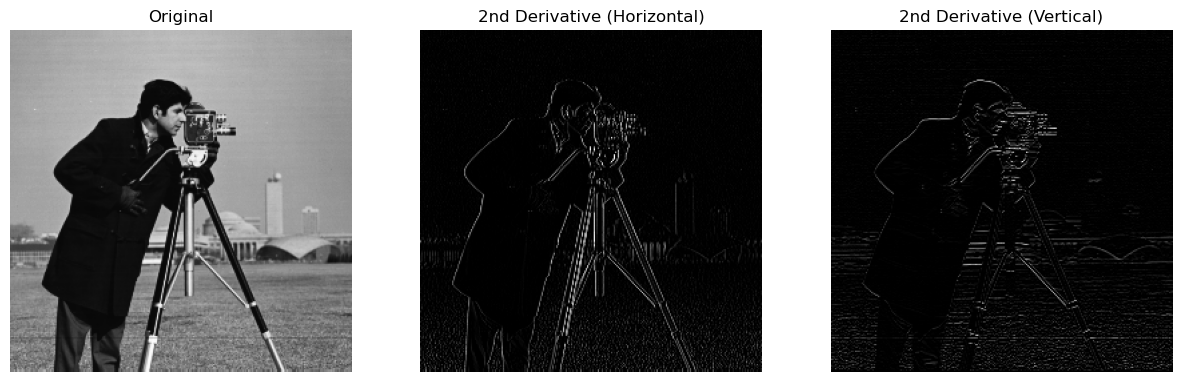

In [ ]:
# 5.2 – Second derivative (Difference of Differences)

# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Manual Kernels
# Horizontal: [1, -2, 1]
k_hor = np.array([[1, -2, 1]], dtype=np.float32)
# Vertical: [1, -2, 1] Transposed
k_ver = np.array([[1], [-2], [1]], dtype=np.float32)

deriv2_h = cv2.filter2D(img, -1, k_hor)
deriv2_v = cv2.filter2D(img, -1, k_ver)

show_3_in_1(img, normalize(deriv2_h), normalize(deriv2_v), "2nd Derivative (Horizontal)", "2nd Derivative (Vertical)")

5.3 Laplacian Filter (4-neighbor)

[ WARN:0@1.593] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@1.593] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@1.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@1.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@1.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@1.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@1.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@1.594] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

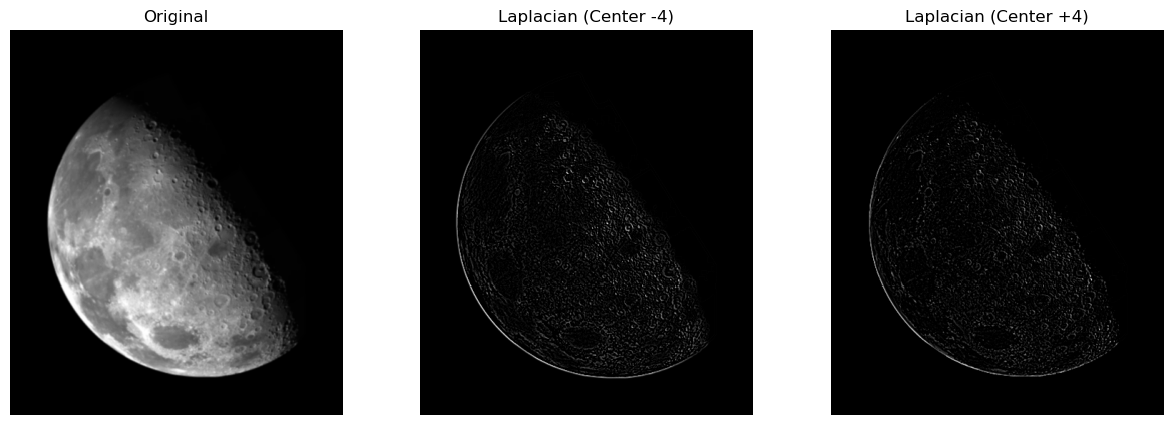

In [ ]:
# 5.3 – Laplacian 4-neighbor filter (Comparing Center -4 vs Center +4)

# Load the image (Moon)
image_path = 'DIP3E_Original_Images_CH03/Fig0338(a)(blurry_moon).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Center -4 (Standard Negative Laplacian)
#  0  1  0
#  1 -4  1
#  0  1  0
k_neg4 = np.array([[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32)

# Center +4 (Standard Positive Laplacian)
#  0 -1  0
# -1  4 -1
#  0 -1  0
k_pos4 = np.array([[0, -1, 0], [-1, 4, -1], [0, -1, 0]], dtype=np.float32)

lap_neg4 = cv2.filter2D(img, -1, k_neg4)
lap_pos4 = cv2.filter2D(img, -1, k_pos4)

show_3_in_1(img, normalize(lap_neg4), normalize(lap_pos4), "Laplacian (Center -4)", "Laplacian (Center +4)")

5.4 Sharpening with Laplacian (Composite Mask)

[ WARN:0@2.011] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@2.011] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@2.011] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@2.011] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@2.011] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@2.011] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@2.011] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@2.011] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

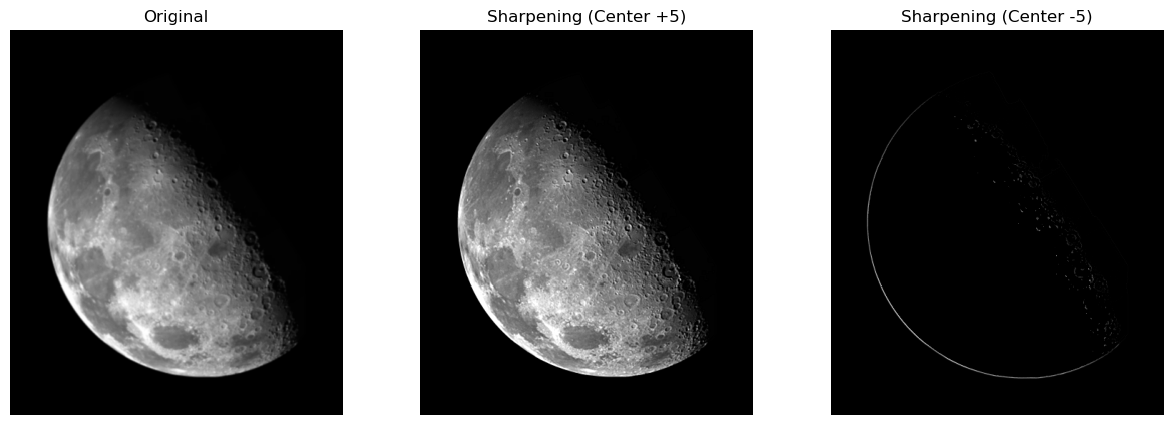

In [ ]:
# 5.4 – Sharpening Filters (Comparing Center +5 vs Center -5)

# Load the image
image_path = 'DIP3E_Original_Images_CH03/Fig0338(a)(blurry_moon).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Center +5 (Standard Sharpening: Original - Laplacian(-4) -> 1 - (-4) = 5)
#  0 -1  0
# -1  5 -1
#  0 -1  0
k_plus5 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)

# Center -5 (Inverted Sharpening or "Unsharp Masking" variant)
#  0  1  0
#  1 -5  1
#  0  1  0
k_minus5 = np.array([[0, 1, 0], [1, -5, 1], [0, 1, 0]], dtype=np.float32)

sharp_p5 = cv2.filter2D(img, -1, k_plus5)
sharp_m5 = cv2.filter2D(img, -1, k_minus5)

show_3_in_1(img, np.clip(sharp_p5,0,255), normalize(sharp_m5), "Sharpening (Center +5)", "Sharpening (Center -5)")

5.5 Laplacian (8-neighbor & High Boost Variants)

[ WARN:0@2.393] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@2.393] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@2.393] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@2.393] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@2.393] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@2.393] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@2.393] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@2.393] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

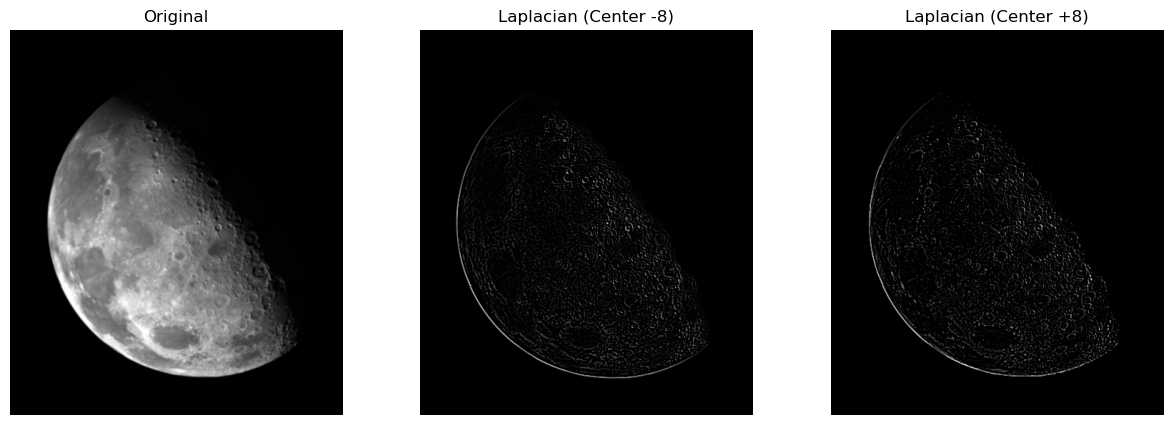

In [ ]:
# 5.5.1 – Laplacian 8-neighbor (Center -8 vs Center +8)

# Load the image
image_path = 'DIP3E_Original_Images_CH03/Fig0338(a)(blurry_moon).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Center -8 (Includes diagonals)
k_neg8 = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], dtype=np.float32)
# Center +8
k_pos8 = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]], dtype=np.float32)

lap_neg8 = cv2.filter2D(img, -1, k_neg8)
lap_pos8 = cv2.filter2D(img, -1, k_pos8)

show_3_in_1(img, normalize(lap_neg8), normalize(lap_pos8), "Laplacian (Center -8)", "Laplacian (Center +8)")

[ WARN:0@2.809] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@2.809] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@2.809] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@2.809] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@2.809] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@2.809] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@2.809] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@2.809] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84e7) encountered
[ WARN:0

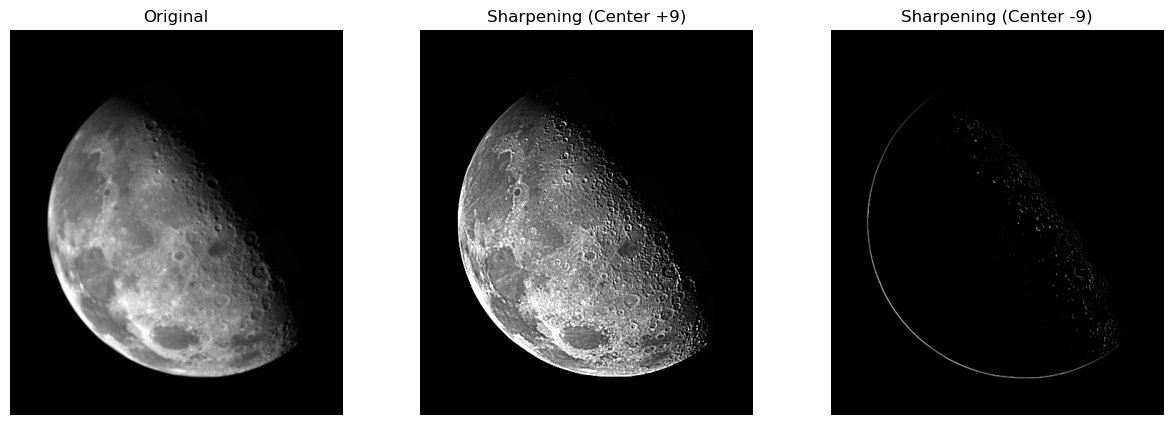

In [ ]:
# 5.5.2 – High Boost / Sharpening 9 (Center +9 vs Center -9)

# Load the image
image_path = 'DIP3E_Original_Images_CH03/Fig0338(a)(blurry_moon).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Center +9 (Standard High Boost: Original - Lap(-8) -> 1 - (-8) = 9)
k_pos9 = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]], dtype=np.float32)

# Center -9
k_neg9 = np.array([[1, 1, 1], [1, -9, 1], [1, 1, 1]], dtype=np.float32)

sharp_p9 = cv2.filter2D(img, -1, k_pos9)
sharp_m9 = cv2.filter2D(img, -1, k_neg9)

show_3_in_1(img, np.clip(sharp_p9,0,255), normalize(sharp_m9), "Sharpening (Center +9)", "Sharpening (Center -9)")

5.6 Roberts Cross Gradient Operator

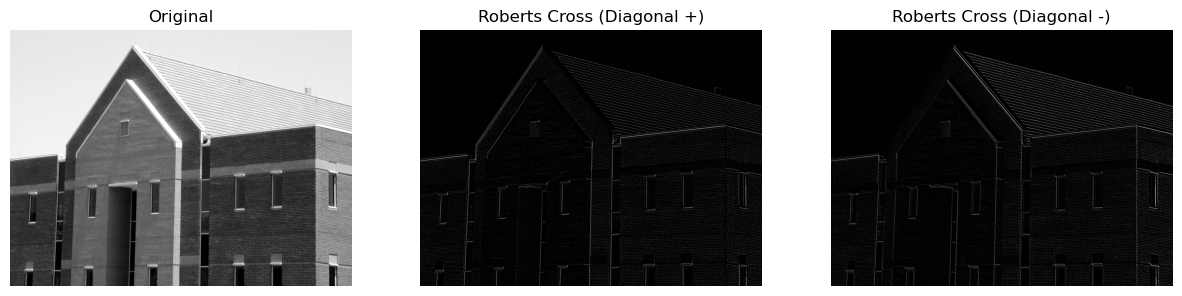

In [ ]:
# 5.6 – Roberts Cross Gradient (Diagonal Derivatives)

# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1016(a)(building_original).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Roberts Gx (Diagonal 1)
# 1  0
# 0 -1
k_rob_x = np.array([[1, 0], [0, -1]], dtype=np.float32)

# Roberts Gy (Diagonal 2)
# 0  1
# -1 0
k_rob_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)

rob_x = cv2.filter2D(img, -1, k_rob_x)
rob_y = cv2.filter2D(img, -1, k_rob_y)

show_3_in_1(img, normalize(rob_x), normalize(rob_y), "Roberts Cross (Diagonal +)", "Roberts Cross (Diagonal -)")

5.7 Prewitt Operator

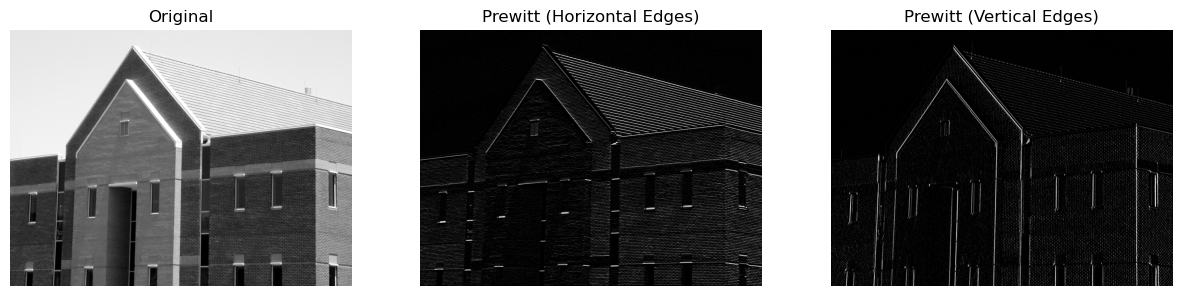

In [ ]:
# 5.7 – Prewitt Operator (Vertical vs Horizontal Edges)

# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1016(a)(building_original).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Prewitt Gx (Vertical filter -> Detects Horizontal Edges)
# -1 -1 -1
#  0  0  0
#  1  1  1
k_prew_x = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]], dtype=np.float32)

# Prewitt Gy (Horizontal filter -> Detects Vertical Edges)
# -1  0  1
# -1  0  1
# -1  0  1
k_prew_y = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)

prew_x = cv2.filter2D(img, -1, k_prew_x)
prew_y = cv2.filter2D(img, -1, k_prew_y)

show_3_in_1(img, normalize(prew_x), normalize(prew_y), "Prewitt (Horizontal Edges)", "Prewitt (Vertical Edges)")

5.8 Sobel Operator

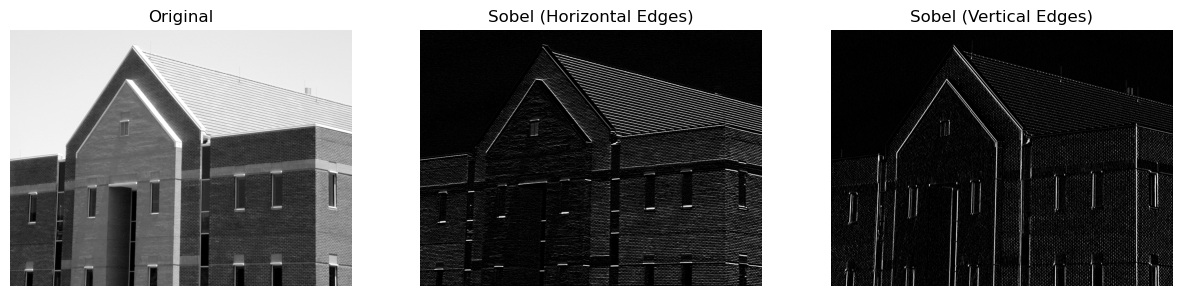

In [ ]:
# 5.8 – Sobel Operator (Vertical vs Horizontal Edges)

# Load the image
image_path = 'DIP3E_Original_Images_CH10/Fig1016(a)(building_original).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Sobel Gx (Vertical filter -> Detects Horizontal Edges)
# -1 -2 -1
#  0  0  0
#  1  2  1
k_sobel_x = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

# Sobel Gy (Horizontal filter -> Detects Vertical Edges)
# -1  0  1
# -2  0  2
# -1  0  1
k_sobel_y = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)

sob_x = cv2.filter2D(img, -1, k_sobel_x)
sob_y = cv2.filter2D(img, -1, k_sobel_y)

show_3_in_1(img, normalize(sob_x), normalize(sob_y), "Sobel (Horizontal Edges)", "Sobel (Vertical Edges)")

5.9 Combinational Spatial Enhancement

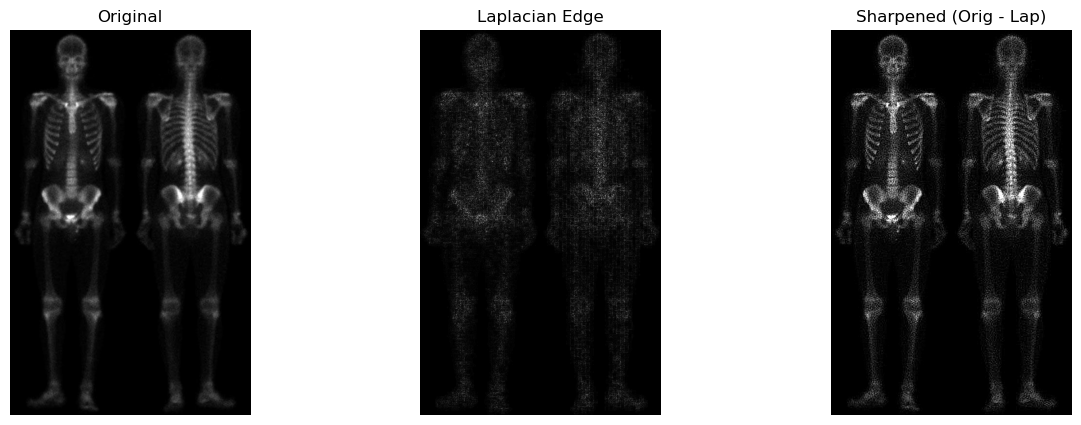

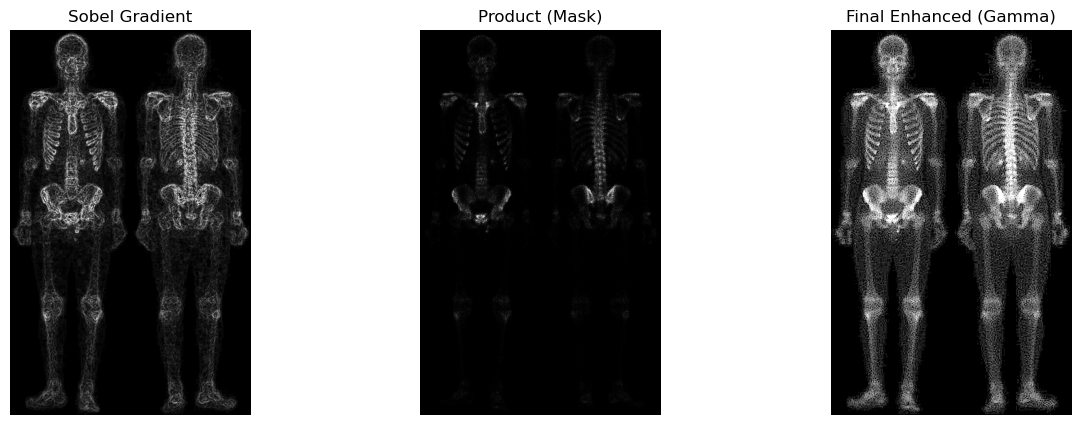

In [ ]:
# 5.9 – Combinational Spatial Enhancement (Skeleton)

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Redefining helper to ensure it accepts 6 arguments (3 images + 3 titles)
def show_3_in_1(img1, img2, img3, title1, title2, title3):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.imshow(img1, cmap='gray'); plt.title(title1); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(img2, cmap='gray'); plt.title(title2); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(img3, cmap='gray'); plt.title(title3); plt.axis('off')
    plt.show()

# Load the image
image_path = 'DIP3E_Original_Images_CH03/Fig0343(a)(skeleton_orig).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Step A: Laplacian (Center -8 for edge detection)
# Note: Using float64 to preserve negative values during calculation
k_lap = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], dtype=np.float32)
lap = cv2.filter2D(img, cv2.CV_64F, k_lap)

# Step B: Sharpened (Original - Laplacian)
# Subtracting the negative center Laplacian adds the edges back
sharp = img.astype(np.float64) - lap
sharp = np.clip(sharp, 0, 255)

# Step C: Sobel Magnitude (Gradient)
sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.abs(sx) + np.abs(sy)

# Step D: Smoothed Sobel (5x5 Box filter)
sobel_smooth = cv2.blur(sobel_mag, (5, 5))

# Step E: Mask Product (Sharpened * Normalized Smoothed Sobel)
mask = sobel_smooth / np.max(sobel_smooth) # Normalize to 0-1
product = sharp * mask

# Step F: Final Addition (Sharpened + Product)
final_img = sharp + product
final_img = np.clip(final_img, 0, 255).astype(np.uint8)

# Step G: Power Law Gamma Transformation
gamma = 0.5
final_gamma = 255 * (final_img / 255.0) ** gamma
final_gamma = np.uint8(np.clip(final_gamma, 0, 255))

# Visualization
# Set 1: Original -> Laplacian -> Sharpened
show_3_in_1(img, np.uint8(np.abs(lap)), np.uint8(sharp),
            "Original", "Laplacian Edge", "Sharpened (Orig - Lap)")

# Set 2: Sobel -> Mask -> Final
show_3_in_1(np.uint8(sobel_mag), np.uint8(product), final_gamma,
            "Sobel Gradient", "Product (Mask)", "Final Enhanced (Gamma)")